#  1- Importing Liberaries 


In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# 2- Importing Data

##     csv

In [2]:
# Load csv comma-separated Dataset

df = pd.read_csv(r"D:\ipselon\roles\ahmed\ROAD_ACCEDENT.csv", header=0,)


In [3]:
# show the first 5 rows of the dataset
df.head()

,status,accident_index,accident_year,accident_reference,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,casualty_severity,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_home_area_type,casualty_imd_decile,lsoa_of_casualty
0,Unvalidated,2022070151244,2022,070151244,2,1,1,2,46,8,3,0,0,0,0,0,9,1,9,E01033378
1,Unvalidated,2022070152668,2022,070152668,1,1,1,1,30,6,3,0,0,0,0,0,9,1,2,E01018551
2,Unvalidated,2022070154696,2022,070154696,1,1,1,2,58,9,3,0,0,0,0,0,9,1,10,E01006134
3,Unvalidated,2022070154696,2022,070154696,2,3,1,2,78,11,3,0,0,0,0,0,9,2,10,E01018724
4,Unvalidated,2022070154696,2022,070154696,3,2,1,1,63,9,3,0,0,0,0,0,9,3,7,W01000578


In [4]:
# SHOW the shape of the dataset
df.shape

(61352, 20)

In [5]:
# SHOW the info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61352 entries, 0 to 61351
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   status                              61352 non-null  object
 1   accident_index                      61352 non-null  object
 2   accident_year                       61352 non-null  int64 
 3   accident_reference                  61352 non-null  object
 4   vehicle_reference                   61352 non-null  int64 
 5   casualty_reference                  61352 non-null  int64 
 6   casualty_class                      61352 non-null  int64 
 7   sex_of_casualty                     61352 non-null  int64 
 8   age_of_casualty                     61352 non-null  int64 
 9   age_band_of_casualty                61352 non-null  int64 
 10  casualty_severity                   61352 non-null  int64 
 11  pedestrian_location                 61352 non-null  in

In [6]:
# SHOW the columns of the dataset
df.columns

Index(['status', 'accident_index', 'accident_year', 'accident_reference',
       'vehicle_reference', 'casualty_reference', 'casualty_class',
       'sex_of_casualty', 'age_of_casualty', 'age_band_of_casualty',
       'casualty_severity', 'pedestrian_location', 'pedestrian_movement',
       'car_passenger', 'bus_or_coach_passenger',
       'pedestrian_road_maintenance_worker', 'casualty_type',
       'casualty_home_area_type', 'casualty_imd_decile', 'lsoa_of_casualty'],
      dtype='object')

In [7]:
# SHOW the index of the dataset
df.index

RangeIndex(start=0, stop=61352, step=1)

In [8]:
df.values


array([['Unvalidated', '2022070151244', 2022, ..., 1, 9, 'E01033378'],
       ['Unvalidated', '2022070152668', 2022, ..., 1, 2, 'E01018551'],
       ['Unvalidated', '2022070154696', 2022, ..., 1, 10, 'E01006134'],
       ...,
       ['Unvalidated', '2022461157256', 2022, ..., 1, 5, 'E01016034'],
       ['Unvalidated', '2022461157316', 2022, ..., 1, 3, 'E01024497'],
       ['Unvalidated', '2022461159841', 2022, ..., 1, 2, 'E01016025']],
      shape=(61352, 20), dtype=object)

# Data Cleaning & EDA Checklist

#  METHODS

## Merging Related Columns

In [9]:
# 1. حالة الحماية (1 = مكشوف/مشاة/دراجة، 0 = محمي/داخل سيارة)
df['protection_status'] = np.where(df['casualty_class'].isin([2, 3]), 1, 0)

# 2. سلوك المشاة (دمج المكان مع الحركة)
df['ped_behavior'] = df['pedestrian_location'].astype(str) + "_" + df['pedestrian_movement'].astype(str)

# 3. نوع المنطقة (دمج التصنيف المكاني مع مؤشر جودة/حرمان المنطقة)
df['zone_type'] = df['casualty_home_area_type'].astype(str) + "_" + df['casualty_imd_decile'].astype(str)

## Deleting unnecesary column

In [10]:
df.columns

Index(['status', 'accident_index', 'accident_year', 'accident_reference',
       'vehicle_reference', 'casualty_reference', 'casualty_class',
       'sex_of_casualty', 'age_of_casualty', 'age_band_of_casualty',
       'casualty_severity', 'pedestrian_location', 'pedestrian_movement',
       'car_passenger', 'bus_or_coach_passenger',
       'pedestrian_road_maintenance_worker', 'casualty_type',
       'casualty_home_area_type', 'casualty_imd_decile', 'lsoa_of_casualty',
       'protection_status', 'ped_behavior', 'zone_type'],
      dtype='object')

In [11]:
df.drop(
    columns=[
    'casualty_class', 'casualty_type', 
    'pedestrian_location', 'pedestrian_movement', 
    'casualty_home_area_type', 'casualty_imd_decile','status', 'accident_year','accident_index' ,'accident_reference','lsoa_of_casualty'
],inplace=True
)

In [12]:
df.columns

Index(['vehicle_reference', 'casualty_reference', 'sex_of_casualty',
       'age_of_casualty', 'age_band_of_casualty', 'casualty_severity',
       'car_passenger', 'bus_or_coach_passenger',
       'pedestrian_road_maintenance_worker', 'protection_status',
       'ped_behavior', 'zone_type'],
      dtype='object')

## column renaming 

In [86]:
# Rename multiple columns

df.rename(
    columns={
        'age_of_casualty': 'casualty_age',
        'sex_of_casualty': 'casualty_sex',
        'casualty_severity': 'severity'
    },
    inplace=True
)

In [14]:
df.head()

,vehicle_reference,casualty_reference,casualty_sex,casualty_age,age_band_of_casualty,severity,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,protection_status,ped_behavior,zone_type
0,2,1,2,46,8,3,0,0,0,0,0_0,1_9
1,1,1,1,30,6,3,0,0,0,0,0_0,1_2
2,1,1,2,58,9,3,0,0,0,0,0_0,1_10
3,2,3,2,78,11,3,0,0,0,0,0_0,2_10
4,3,2,1,63,9,3,0,0,0,0,0_0,3_7


## 1.Check Missing Values


In [15]:
# CHECK for missing values in the dataset
df.isnull().sum()

vehicle_reference                     0
casualty_reference                    0
casualty_sex                          0
casualty_age                          0
age_band_of_casualty                  0
severity                              0
car_passenger                         0
bus_or_coach_passenger                0
pedestrian_road_maintenance_worker    0
protection_status                     0
ped_behavior                          0
zone_type                             0
dtype: int64

In [16]:
# Check the percentage of missing values in each column
df.isnull().mean() * 100

vehicle_reference                     0.0
casualty_reference                    0.0
casualty_sex                          0.0
casualty_age                          0.0
age_band_of_casualty                  0.0
severity                              0.0
car_passenger                         0.0
bus_or_coach_passenger                0.0
pedestrian_road_maintenance_worker    0.0
protection_status                     0.0
ped_behavior                          0.0
zone_type                             0.0
dtype: float64

## -----------------------------------------------------------------------------------

## 2-Check Duplicates

In [85]:
# Check for duplicate rows in the dataset
df.duplicated().sum()


np.int64(0)

In [84]:
# Show duplicate rows in the dataset
df[df.duplicated()]


,vehicle_reference,casualty_reference,casualty_sex,casualty_age,age_band_of_casualty,severity,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,protection_status,ped_behavior,zone_type


In [83]:
# Remove duplicate rows from the dataset
df = df.drop_duplicates()


## --------------------------------------------------------------------------------

## 3-Unique Values

In [20]:
# Check for unique values in each column

df.nunique()

vehicle_reference                      11
casualty_reference                     18
casualty_sex                            4
casualty_age                          102
age_band_of_casualty                   12
severity                                3
car_passenger                           5
bus_or_coach_passenger                  7
pedestrian_road_maintenance_worker      4
protection_status                       2
ped_behavior                           72
zone_type                              34
dtype: int64

In [21]:
# Check unique values for each column
for col in df.columns:
    count = df[col].nunique()
    
    print(col)
    print("Count:", count)
    
    if count <= 20:
        print("Values:", df[col].unique())
    else:
        print("Values: Too many unique values")
    
    print()

vehicle_reference
Count: 11
Values: [  2   1   3   4   5   8   6   9 227   7  61]

casualty_reference
Count: 18
Values: [  1   3   2   4   5   6   7   8   9  10  11  12  14  15  13  16  22 148]

casualty_sex
Count: 4
Values: [ 2  1 -1  9]

casualty_age
Count: 102
Values: Too many unique values

age_band_of_casualty
Count: 12
Values: [ 8  6  9 11  4 10  3  7  2  5  1 -1]

severity
Count: 3
Values: [3 2 1]

car_passenger
Count: 5
Values: [ 0  2  1 -1  9]

bus_or_coach_passenger
Count: 7
Values: [ 0  2  4  1  3 -1  9]

pedestrian_road_maintenance_worker
Count: 4
Values: [ 0  2  1 -1]

protection_status
Count: 2
Values: [0 1]

ped_behavior
Count: 72
Values: Too many unique values

zone_type
Count: 34
Values: Too many unique values



In [82]:
# Check the distribution of values in each column
df['vehicle_reference'].value_counts()


vehicle_reference
1    12976
2     6856
3      957
Name: count, dtype: int64

In [23]:
# لو لاحظنا قيم شاذه وعايزين نعرفها فين لنكتب الكود ده ونتأكد منهم 
df[df['vehicle_reference'].isin([61, 227])]

,vehicle_reference,casualty_reference,casualty_sex,casualty_age,age_band_of_casualty,severity,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,protection_status,ped_behavior,zone_type
12438,227,1,2,14,3,3,0,0,0,1,1_3,1_2
27132,61,1,1,21,5,3,0,0,0,0,0_0,2_8


In [24]:
df.drop([12438, 27132], inplace=True) # الأرقام تمثل رقم الصف (Index)

In [25]:
df['casualty_reference'].value_counts()

casualty_reference
1      21233
2       7076
3       2530
4        891
5        322
6         98
7         37
8         15
9         11
10        10
11         7
12         6
14         4
13         4
15         3
16         2
22         1
148        1
Name: count, dtype: int64

In [26]:
df[df['casualty_reference'].isin([22, 148])]

,vehicle_reference,casualty_reference,casualty_sex,casualty_age,age_band_of_casualty,severity,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,protection_status,ped_behavior,zone_type
45133,1,22,1,24,5,3,1,0,0,1,0_0,1_6
52689,2,148,2,21,5,3,0,0,0,0,0_0,1_3


In [27]:
df.drop([45133, 52689], inplace=True)

## --------------------------------------------------------------------------------

## 4- Check Data Types

In [28]:
df.dtypes

vehicle_reference                      int64
casualty_reference                     int64
casualty_sex                           int64
casualty_age                           int64
age_band_of_casualty                   int64
severity                               int64
car_passenger                          int64
bus_or_coach_passenger                 int64
pedestrian_road_maintenance_worker     int64
protection_status                      int64
ped_behavior                          object
zone_type                             object
dtype: object

## --------------------------------------------------------------------------------

# 5- Check Invalid / Unexpected Values

In [29]:
# Summary statistics for the dataset
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
vehicle_reference,32249.0,1.46,0.65,1.0,1.0,1.0,2.0,9.0
casualty_reference,32249.0,1.54,0.98,1.0,1.0,1.0,2.0,16.0
casualty_sex,32249.0,1.45,0.56,-1.0,1.0,1.0,2.0,9.0
casualty_age,32249.0,38.08,22.35,-1.0,20.0,35.0,55.0,101.0
age_band_of_casualty,32249.0,6.35,2.78,-1.0,4.0,6.0,8.0,11.0
severity,32249.0,2.70,0.51,1.0,2.0,3.0,3.0,3.0
car_passenger,32249.0,0.35,0.76,-1.0,0.0,0.0,1.0,9.0
bus_or_coach_passenger,32249.0,0.09,0.57,-1.0,0.0,0.0,0.0,9.0
pedestrian_road_maintenance_worker,32249.0,0.06,0.35,-1.0,0.0,0.0,0.0,2.0
protection_status,32249.0,0.56,0.50,0.0,0.0,1.0,1.0,1.0


In [81]:

df['casualty_age'].value_counts().sort_index()

casualty_age
0      14
1      12
2      34
3      75
4     108
     ... 
95      4
96      3
97      1
98      1
99      4
Name: count, Length: 100, dtype: int64

In [80]:
# Remove rows where 'age_of_casualty' is -1
df = df[df['casualty_age'] != -1]


In [32]:
df['casualty_sex'].value_counts().sort_index()

casualty_sex
-1      156
 1    16788
 2    14640
 9        8
Name: count, dtype: int64

In [33]:
df = df[df['casualty_sex'] != -1]

In [34]:
df['car_passenger'].value_counts().sort_index()

car_passenger
-1      281
 0    23279
 1     4876
 2     2976
 9       24
Name: count, dtype: int64

In [35]:
df = df[df['car_passenger'] != -1]

In [36]:
df['bus_or_coach_passenger'].value_counts().sort_index()

bus_or_coach_passenger
-1       16
 0    30381
 1       27
 2       51
 3      243
 4      434
 9        3
Name: count, dtype: int64

In [37]:
df = df[df['bus_or_coach_passenger'] != -1]

In [38]:
df['pedestrian_road_maintenance_worker'].value_counts().sort_index()

pedestrian_road_maintenance_worker
-1      104
 0    29962
 1      112
 2      961
Name: count, dtype: int64

In [39]:
df = df[df['pedestrian_road_maintenance_worker'] != -1]

In [40]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
vehicle_reference,31035.0,1.46,0.66,1.0,1.0,1.0,2.0,9.0
casualty_reference,31035.0,1.53,0.97,1.0,1.0,1.0,2.0,16.0
casualty_sex,31035.0,1.47,0.51,1.0,1.0,1.0,2.0,9.0
casualty_age,31035.0,39.03,21.87,0.0,21.0,36.0,56.0,101.0
age_band_of_casualty,31035.0,6.52,2.60,1.0,5.0,7.0,9.0,11.0
severity,31035.0,2.69,0.51,1.0,2.0,3.0,3.0,3.0
car_passenger,31035.0,0.36,0.69,0.0,0.0,0.0,1.0,9.0
bus_or_coach_passenger,31035.0,0.08,0.55,0.0,0.0,0.0,0.0,9.0
pedestrian_road_maintenance_worker,31035.0,0.07,0.35,0.0,0.0,0.0,0.0,2.0
protection_status,31035.0,0.55,0.50,0.0,0.0,1.0,1.0,1.0


In [41]:
df.shape

(31035, 12)

## 6- Check Outliers

In [42]:

# Q1 = data['age_of_casualty'].quantile(0.25)
# Q3 = data['age_of_casualty'].quantile(0.75)

# IQR = Q3 - Q1

# lower = Q1 - 1.5 * IQR
# upper = Q3 + 1.5 * IQR

# data[(data['age_of_casualty'] < lower) | (data['age_of_casualty'] > upper)]

In [43]:
from datasist.structdata import detect_outliers

outlier_indices = detect_outliers(df, 0, ['casualty_sex'])
outlier_indices

[2076, 2584, 11160, 19691, 26719, 40397, 40957, 42326]

In [44]:
df.loc[outlier_indices]

,vehicle_reference,casualty_reference,casualty_sex,casualty_age,age_band_of_casualty,severity,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,protection_status,ped_behavior,zone_type
2076,1,1,9,35,6,3,0,0,0,0,0_0,1_10
2584,2,3,9,42,7,3,1,0,0,1,0_0,2_7
11160,2,1,9,32,6,3,0,0,0,0,0_0,2_9
19691,1,1,9,25,5,3,0,0,0,0,0_0,1_-1
26719,2,1,9,25,5,3,1,0,0,1,0_0,1_9
40397,2,1,9,30,6,3,0,0,0,0,0_0,1_3
40957,2,1,9,41,7,3,0,0,0,0,0_0,-1_-1
42326,1,1,9,17,4,3,0,0,0,0,0_0,1_6


In [45]:
df.drop(outlier_indices, axis= 0,inplace=True)

In [46]:
# Import Plotly Graph Objects
# بنستخدمه عشان ننشئ الـ Box Plot نفسه
import plotly.graph_objects as go
from plotly.subplots import make_subplots

numeric_cols = df.select_dtypes(include='number').columns

rows = (len(numeric_cols) + 1) // 2


# إنشاء الـ Subplots
fig = make_subplots(

    # عدد الصفوف في الشكل
    rows=rows,
    cols=2,
    subplot_titles=numeric_cols,
    horizontal_spacing=0.14,
    vertical_spacing=0.04
)

for i, column in enumerate(numeric_cols):
    row = i // 2 + 1
    col = i % 2 + 1
    fig.add_trace(

        go.Box(
            x=df[column],
            name=column,
            orientation='h',
            boxpoints='outliers'
        ),
        row=row,
        col=col
    )
    if (df[column] > 0).all():
        fig.update_xaxes(
            type='log',
            row=row,
            col=col
        )
fig.update_layout(
    width=1400,
    height=rows * 250,
    showlegend=False,
    margin=dict(
        l=0,
        r=40,
        t=50,
        b=30
    )
)

fig.show()

In [47]:
# to calculate the outliers for each numeric column using the IQR method
outlier_results = []

for column in numeric_cols:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(df)) * 100

    outlier_results.append({
        'Column': column,
        'Outlier Count': outlier_count,
        'Outlier Percentage': round(outlier_percentage, 2)
    })

outlier_results = pd.DataFrame(outlier_results)

outlier_results

,Column,Outlier Count,Outlier Percentage
0,vehicle_reference,320,1.03
1,casualty_reference,1311,4.23
2,casualty_sex,0,0.00
3,casualty_age,0,0.00
4,age_band_of_casualty,0,0.00
5,severity,0,0.00
6,car_passenger,24,0.08
7,bus_or_coach_passenger,758,2.44
8,pedestrian_road_maintenance_worker,1073,3.46
9,protection_status,0,0.00


In [48]:
# dropping outlayers from the dataset

outlier_columns = [
    'vehicle_reference', 
    'casualty_reference', 
    'car_passenger', 
    'bus_or_coach_passenger', 
    'pedestrian_road_maintenance_worker'
]

# تطبيق طريقة المدى الربيعي (IQR) لاستبعاد الصفوف الشاذة
for col in outlier_columns:
    # حساب الربع الأول (25%) والربع الثالث (75%)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    # حساب المدى الربيعي
    IQR = Q3 - Q1
    
    # تحديد الحدود الإحصائية الدنيا والعليا
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # تصفية مصفوفة البيانات والاحتفاظ بالقيم داخل النطاق الطبيعي فقط
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]


In [49]:
# Import Plotly Graph Objects
# بنستخدمه عشان ننشئ الـ Box Plot نفسه
import plotly.graph_objects as go
from plotly.subplots import make_subplots

numeric_cols = df.select_dtypes(include='number').columns

rows = (len(numeric_cols) + 1) // 2


# إنشاء الـ Subplots
fig = make_subplots(

    # عدد الصفوف في الشكل
    rows=rows,
    cols=2,
    subplot_titles=numeric_cols,
    horizontal_spacing=0.14,
    vertical_spacing=0.04
)

for i, column in enumerate(numeric_cols):
    row = i // 2 + 1
    col = i % 2 + 1
    fig.add_trace(

        go.Box(
            x=df[column],
            name=column,
            orientation='h',
            boxpoints='outliers'
        ),
        row=row,
        col=col
    )
    if (df[column] > 0).all():
        fig.update_xaxes(
            type='log',
            row=row,
            col=col
        )
fig.update_layout(
    width=1400,
    height=rows * 250,
    showlegend=False,
    margin=dict(
        l=0,
        r=40,
        t=50,
        b=30
    )
)

fig.show()

## 7- Check Relationships

In [50]:

corr = df.select_dtypes(include='number').corr()
import plotly.express as px

fig = px.imshow( corr,text_auto=True,aspect='auto',title='Correlation Matrix',color_continuous_scale='RdBu',)

fig.update_layout(
    width=1000,
    height=800
)
fig.show()

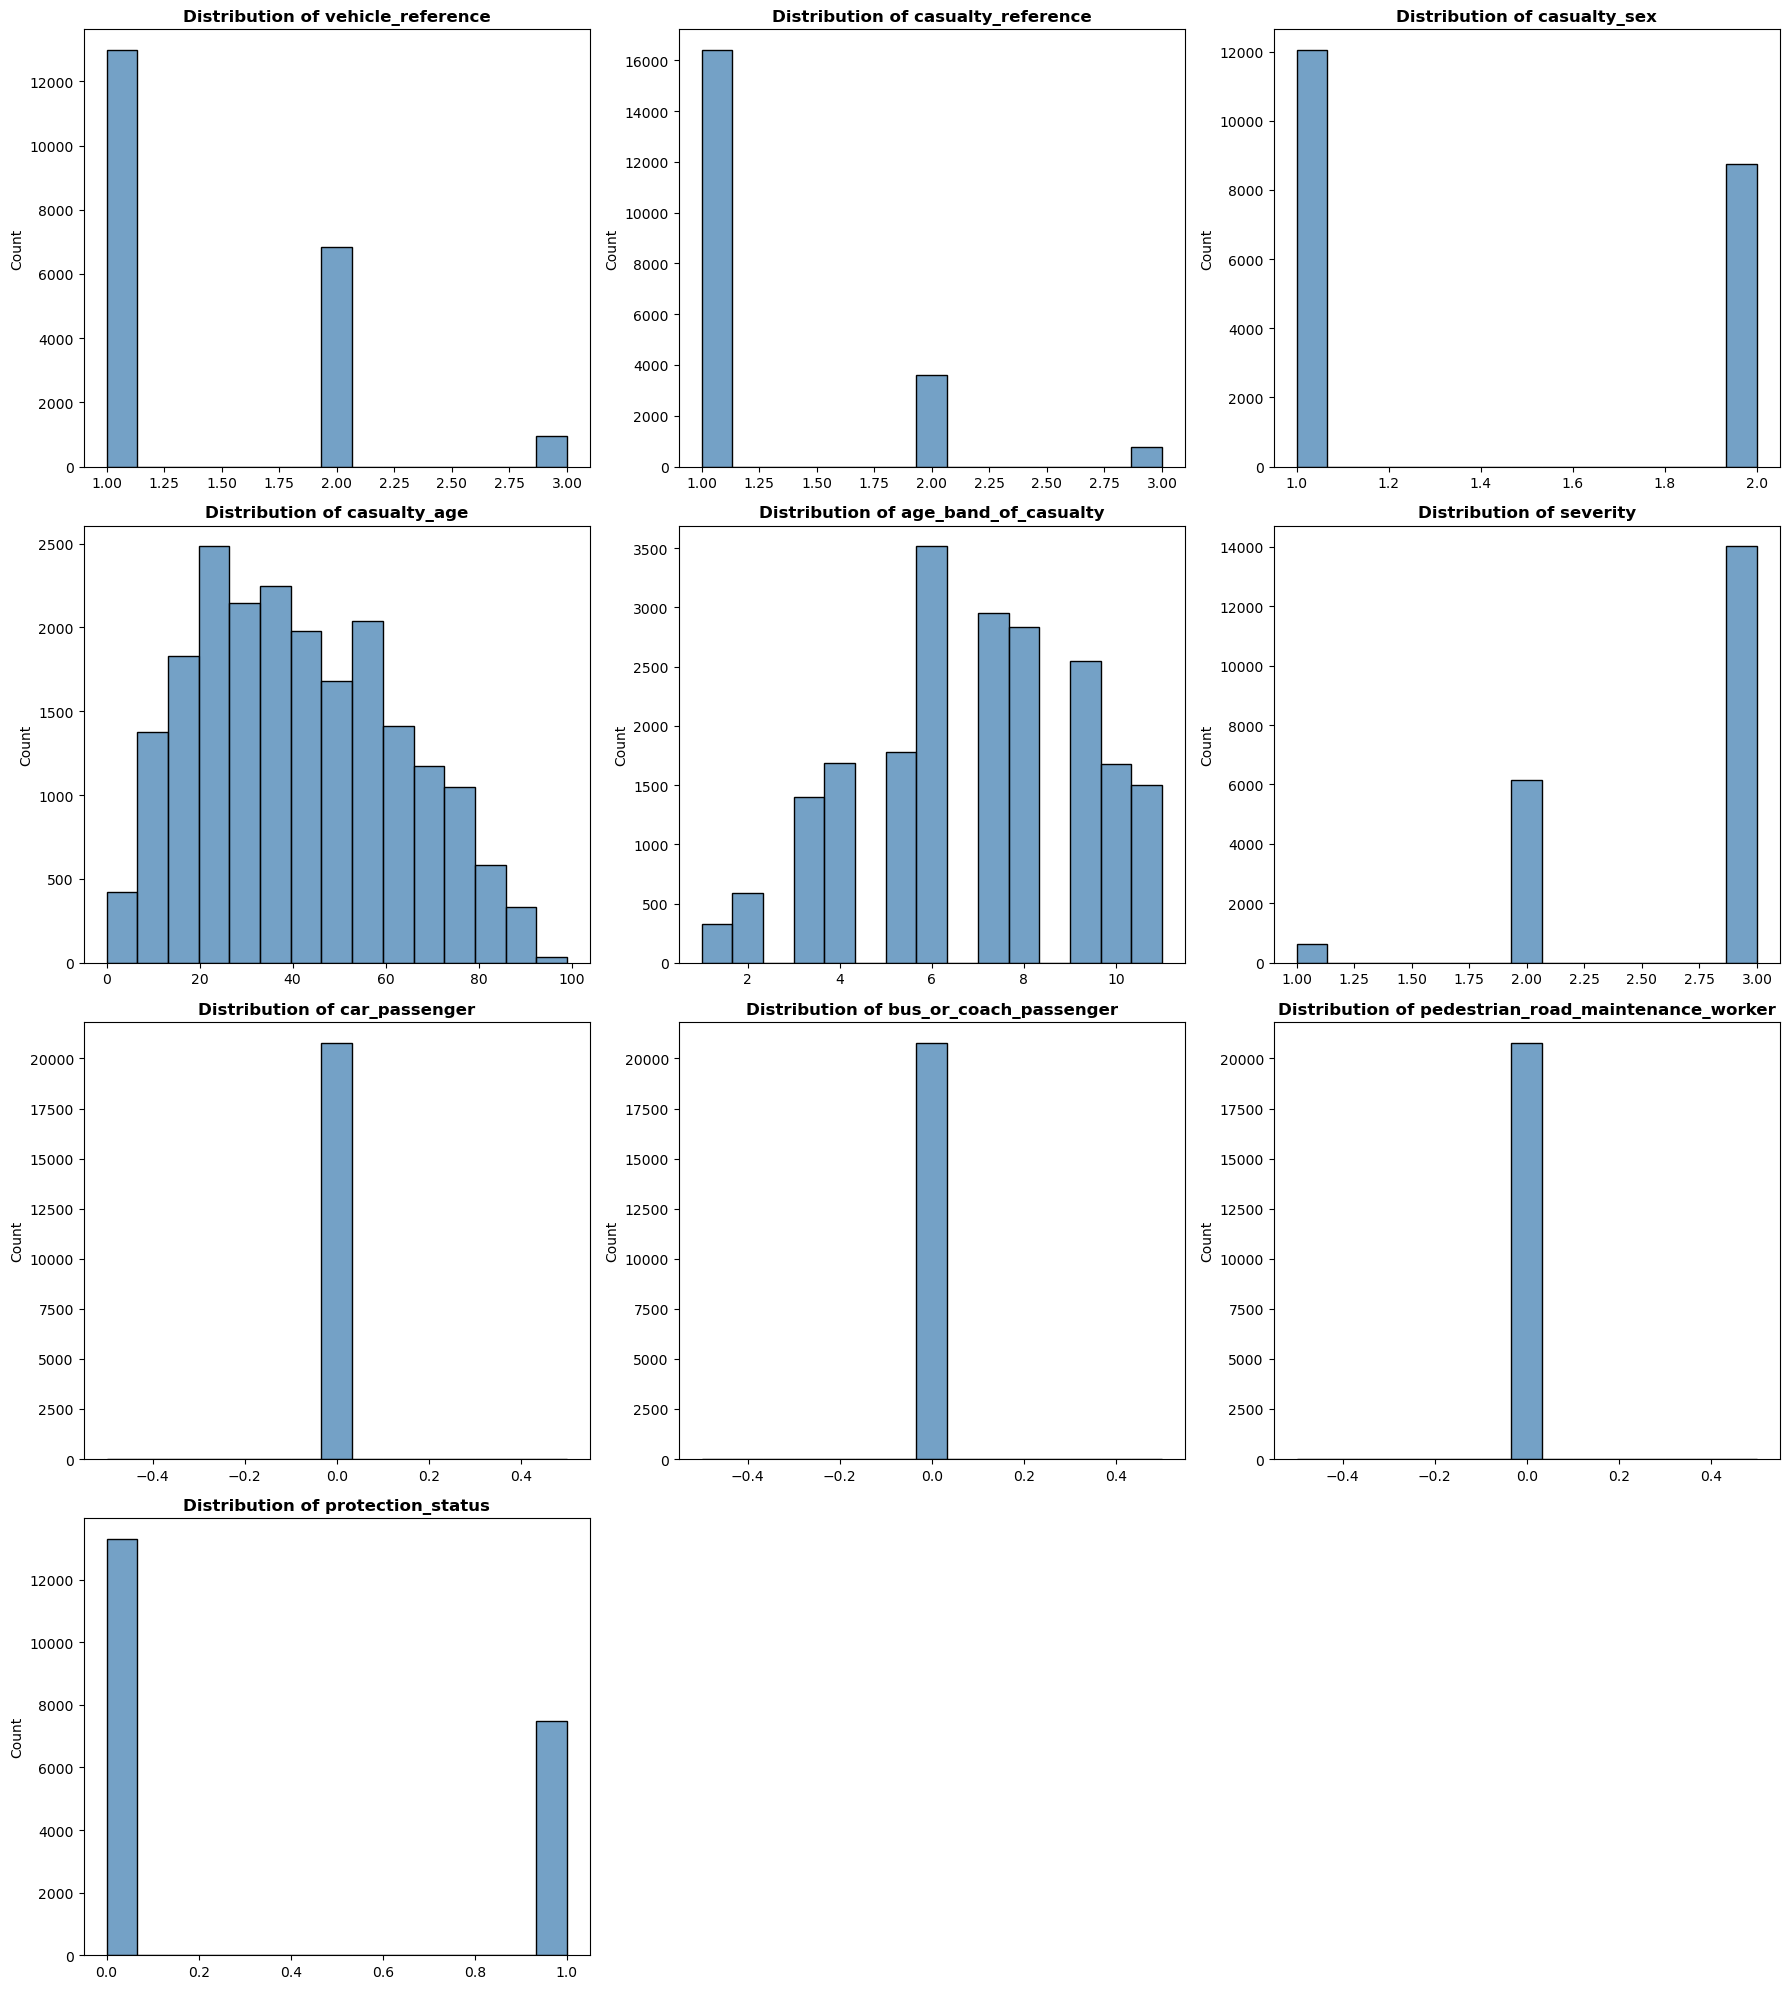

In [51]:
# normal distribution of numeric columns
numeric_cols = df.select_dtypes(include='number').columns

# 2. تجهيز لوحة الرسم (Grid)
# تحديد عدد الصفوف بناءً على عدد الأعمدة (3 رسومات في كل صف)
num_plots = len(numeric_cols)
rows = (num_plots // 3) + (1 if num_plots % 3 != 0 else 0)

fig, axes = plt.subplots(nrows=rows, ncols=3, figsize=(18, 5 * rows))
axes = axes.flatten() # تسطيح المصفوفة لتسهيل المرور عليها بحلقة تكرارية (Loop)

# 3. رسم المدرج التكراري لكل عمود
for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, bins=15, ax=axes[i], color='steelblue', kde=False)
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

# 4. حذف أي إطارات (Subplots) فارغة زائدة في الشبكة
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 5. ضبط المسافات بين الرسومات وعرضها
plt.tight_layout()
plt.show()

## 8- Analyze Relationships

## 1 -  Bivariate Analysis

### 1 - Which casualty severity has the highest number of casualties?

In [52]:
severity_counts = (
    df['severity']
    .value_counts()
    .sort_values(ascending=False)
    .reset_index()
)

severity_counts.columns = ['Severity', 'Casualties']

severity_counts

,Severity,Casualties
0,3,14010
1,2,6156
2,1,623


In [53]:
fig1 = px.bar(
    severity_counts,
    x='Severity',
    y='Casualties',
    title='Number of Casualties by Severity',
    text_auto=True,
    labels={
        'Severity': 'Casualty Severity',
        'Casualties': 'Number of Casualties'
    },
    color='Casualties',
    color_continuous_scale='Viridis'
)

fig1.update_traces(textposition='outside')

fig1.update_layout(
    xaxis_type='category'
)

fig1.show()

### 2 - What are the top 10 age bands by number of casualties?

In [54]:
top_age_bands = (
    df['age_band_of_casualty']
    .value_counts()
    .sort_values(ascending=False)
    .reset_index()
    .head(10)
)

top_age_bands.columns = ['Age_Band', 'Casualties']

top_age_bands

,Age_Band,Casualties
0,6,3514
1,7,2948
2,8,2838
3,9,2543
4,5,1775
5,4,1684
6,10,1675
7,11,1499
8,3,1400
9,2,586


In [55]:
fig2 = px.bar(
    top_age_bands,
    x='Age_Band',
    y='Casualties',
    title='Top Age Bands by Number of Casualties',
    text_auto=True,
    labels={
        'Age_Band': 'Age Band',
        'Casualties': 'Number of Casualties'
    },
    color='Casualties',
    color_continuous_scale='Blues'
)

fig2.update_traces(textposition='outside')

fig2.update_layout(
    xaxis_type='category'
)

fig2.show()

### 3 - What are the casualty severity levels with the highest number of casualties by sex?

In [56]:
top_severity_sex = (
    df.groupby(['casualty_sex', 'severity'])
      .size()
      .reset_index(name='Casualties')
      .sort_values('Casualties', ascending=False)
      .head(5)
)

top_severity_sex

,casualty_sex,severity,Casualties
2,1,3,7722
5,2,3,6288
1,1,2,3837
4,2,2,2319
0,1,1,483


In [57]:
fig3 = px.bar(
    top_severity_sex,
    x='casualty_sex',
    y='Casualties',
    color='severity',
    title='Top 5 Casualty Severity Groups by Sex',
    text_auto=True,
    labels={
        'casualty_sex': 'Sex',
        'Casualties': 'Number of Casualties',
        'severity': 'Severity'
    },
    color_continuous_scale='Magma'
)

fig3.update_traces(textposition='outside')

fig3.update_layout(
    xaxis_type='category'
)

fig3.show()

### 4 - What are the top 10 protection status groups by number of casualties?

In [58]:
top_protection = (
    df['protection_status']
    .value_counts()
    .sort_values(ascending=False)
    .reset_index()
)

top_protection.columns = ['Protection_Status', 'Casualties']

top_protection

,Protection_Status,Casualties
0,0,13297
1,1,7492


In [59]:
fig4 = px.bar(
    top_protection,
    x='Protection_Status',
    y='Casualties',
    title='Number of Casualties by Protection Status',
    text_auto=True,
    labels={
        'Protection_Status': 'Protection Status',
        'Casualties': 'Number of Casualties'
    },
    color='Casualties',
    color_continuous_scale='Sunset'
)

fig4.update_traces(textposition='outside')

fig4.update_layout(
    xaxis_type='category'
)

fig4.show()

## 2 - Multivariate Analysis

### 1 - How does casualty severity vary across age bands and sex?

In [60]:
age_sex_severity = (
    df.groupby([
        'age_band_of_casualty',
        'casualty_sex',
        'severity'
    ])
    .size()
    .reset_index(name='Casualties')
)

age_sex_severity

,age_band_of_casualty,casualty_sex,severity,Casualties
0,1,1,1,2
1,1,1,2,52
2,1,1,3,133
3,1,2,1,1
4,1,2,2,40
...,...,...,...,...
59,11,1,2,266
60,11,1,3,547
61,11,2,1,26
62,11,2,2,240


In [61]:
fig5 = px.bar(
    age_sex_severity,
    x='age_band_of_casualty',
    y='Casualties',
    color='severity',
    facet_col='casualty_sex',
    barmode='group',
    title='Casualty Severity Across Age Bands and Sex',
    text_auto=True,
    labels={
        'age_band_of_casualty': 'Age Band',
        'Casualties': 'Number of Casualties',
        'severity': 'Severity',
        'casualty_sex': 'Sex'
    },
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig5.update_traces(
    textposition='outside'
)

fig5.update_layout(
    template='plotly_white',
    legend_title_text='Severity'
)

fig5.show()

### 2 - How does casualty severity vary across protection status and sex?

In [62]:
protection_sex_severity = (
    df.groupby([
        'protection_status',
        'casualty_sex',
        'severity'
    ])
    .size()
    .reset_index(name='Casualties')
)

protection_sex_severity

,protection_status,casualty_sex,severity,Casualties
0,0,1,1,379
1,0,1,2,2613
2,0,1,3,5033
3,0,2,1,72
4,0,2,2,1309
5,0,2,3,3891
6,1,1,1,104
7,1,1,2,1224
8,1,1,3,2689
9,1,2,1,68


In [63]:
fig6 = px.bar(
    protection_sex_severity,
    x='protection_status',
    y='Casualties',
    color='severity',
    facet_col='casualty_sex',
    barmode='group',
    title='Casualty Severity Across Protection Status and Sex',
    text_auto=True,
    labels={
        'protection_status': 'Protection Status',
        'Casualties': 'Number of Casualties',
        'severity': 'Severity',
        'casualty_sex': 'Sex'
    },
    color_discrete_sequence=px.colors.qualitative.Vivid
)

fig6.update_traces(
    textposition='outside'
)

fig6.update_layout(
    template='plotly_white',
    legend_title_text='Severity'
)

fig6.show()

## 9 - Final Data Check

In [64]:
print("Final Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Final Dataset Shape: (20789, 12)

Column Names:
['vehicle_reference', 'casualty_reference', 'casualty_sex', 'casualty_age', 'age_band_of_casualty', 'severity', 'car_passenger', 'bus_or_coach_passenger', 'pedestrian_road_maintenance_worker', 'protection_status', 'ped_behavior', 'zone_type']

Missing Values:
vehicle_reference                     0
casualty_reference                    0
casualty_sex                          0
casualty_age                          0
age_band_of_casualty                  0
severity                              0
car_passenger                         0
bus_or_coach_passenger                0
pedestrian_road_maintenance_worker    0
protection_status                     0
ped_behavior                          0
zone_type                             0
dtype: int64

Duplicate Rows:
0

Data Types:
vehicle_reference                      int64
casualty_reference                     int64
casualty_sex                           int64
casualty_age                    

## 10 - Save Cleaned Data

In [65]:
df.to_csv("ROAD_ACCEDENT_CLEANED.csv", index=False)

print("Cleaned dataset saved successfully.")
print("File: ROAD_ACCEDENT_CLEANED.csv")

Cleaned dataset saved successfully.
File: ROAD_ACCEDENT_CLEANED.csv


# 11 - Streamlit Dashboard

In [78]:
%%writefile ROAD_ACCIDENT_ANALYSIS.py

import streamlit as st
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go


# ============================================================
# 1. PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Road Accident Analysis",
    layout="wide"
)


# ============================================================
# 2. READ CLEANED DATA
# ============================================================

df = pd.read_csv("ROAD_ACCEDENT_CLEANED.csv")


# ============================================================
# 3. DASHBOARD HEADER
# ============================================================

st.title("Road Accident Analysis")

st.markdown(
    """
    ### Project Overview

    This project analyzes road accident casualty data after data cleaning,
    preprocessing, and exploratory data analysis. The dashboard presents
    the final cleaned dataset and the main statistical relationships
    identified during the analysis.
    """
)

st.markdown("---")


# ============================================================
# 4. CREATE PAGES / TABS
# ============================================================

tab1, tab2, tab3, tab4 = st.tabs([
    "Project Overview",
    "Bivariate Analysis",
    "Multivariate Analysis",
    "Data Explorer"
])


# ============================================================
# TAB 1 — PROJECT OVERVIEW
# ============================================================

with tab1:

    st.header("Project Overview")

    st.markdown(
        """
        The dataset contains casualty-level records from road accidents.
        Data preprocessing was performed to remove duplicate records,
        handle invalid coded values, construct related variables, and
        obtain the final analysis dataset.
        """
    )

    # --------------------------------------------------------
    # Dataset Summary
    # --------------------------------------------------------

    st.subheader("Dataset Summary")

    col1, col2, col3, col4 = st.columns(4)

    with col1:
        st.metric(
            "Casualty Records",
            f"{len(df):,}"
        )

    with col2:
        st.metric(
            "Variables",
            df.shape[1]
        )

    with col3:
        st.metric(
            "Missing Values",
            int(df.isnull().sum().sum())
        )

    with col4:
        st.metric(
            "Duplicate Rows",
            int(df.duplicated().sum())
        )

    st.markdown("---")


    # --------------------------------------------------------
    # Column Description
    # --------------------------------------------------------

    st.subheader("Final Dataset Variables")

    column_description = pd.DataFrame({
        "Column": [
            "vehicle_reference",
            "casualty_reference",
            "casualty_sex",
            "casualty_age",
            "age_band_of_casualty",
            "severity",
            "car_passenger",
            "bus_or_coach_passenger",
            "pedestrian_road_maintenance_worker",
            "protection_status",
            "ped_behavior",
            "zone_type"
        ],

        "Description": [
            "Reference code identifying the vehicle associated with the casualty record.",
            "Reference code associated with the casualty record.",
            "Coded sex of the casualty.",
            "Age of the casualty.",
            "Coded age-band category of the casualty.",
            "Coded casualty severity level.",
            "Coded indicator describing the casualty's car passenger status.",
            "Coded indicator describing the casualty's bus or coach passenger status.",
            "Coded indicator describing whether the casualty was a pedestrian road maintenance worker.",
            "Derived protection-status indicator created from casualty class.",
            "Combined variable representing pedestrian location and pedestrian movement.",
            "Combined variable representing casualty home-area type and casualty IMD decile."
        ]
    })

    st.dataframe(
        column_description,
        use_container_width=True,
        hide_index=True
    )

    st.markdown("---")


    # --------------------------------------------------------
    # Dataset Preview
    # --------------------------------------------------------

    st.subheader("Dataset Preview")

    st.dataframe(
        df.head(15),
        use_container_width=True
    )

    st.markdown("---")


    # --------------------------------------------------------
    # Distribution Analysis
    # --------------------------------------------------------

    st.subheader("Distribution of Numerical Variables")

    numeric_columns = df.select_dtypes(
        include=np.number
    ).columns.tolist()

    # First row
    col1, col2 = st.columns(2)

    with col1:

        selected_num_1 = st.selectbox(
            "Select first variable:",
            numeric_columns,
            key="distribution_1"
        )

        fig_dist_1 = px.histogram(
            df,
            x=selected_num_1,
            nbins=20,
            title=f"Distribution of {selected_num_1}",
            color_discrete_sequence=["#636EFA"]
        )

        fig_dist_1.update_layout(
            xaxis_title=selected_num_1,
            yaxis_title="Frequency"
        )

        st.plotly_chart(
            fig_dist_1,
            use_container_width=True
        )



    st.markdown("---")


    # --------------------------------------------------------
    # Correlation Heatmap
    # --------------------------------------------------------

    st.subheader("Correlation Heatmap")

    corr = df.select_dtypes(
        include=np.number
    ).corr()

    fig_corr = px.imshow(
        corr,
        text_auto=".2f",
        aspect="auto",
        title="Correlation Matrix of Numerical Variables",
        color_continuous_scale="RdBu_r",
        zmin=-1,
        zmax=1
    )

    fig_corr.update_layout(
        height=750
    )

    st.plotly_chart(
        fig_corr,
        use_container_width=True
    )


# ============================================================
# TAB 2 — BIVARIATE ANALYSIS
# ============================================================

with tab2:

    st.header("Bivariate Analysis")

    # --------------------------------------------------------
    # Question 1
    # --------------------------------------------------------

    st.subheader(
        "1. Which casualty severity has the highest number of casualties?"
    )

    severity_counts = (
        df["severity"]
        .value_counts()
        .sort_values(ascending=False)
        .reset_index()
    )

    severity_counts.columns = [
        "Severity",
        "Casualties"
    ]

    fig1 = px.bar(
        severity_counts,
        x="Severity",
        y="Casualties",
        title="Number of Casualties by Severity",
        text_auto=True,
        color="Casualties",
        color_continuous_scale="Viridis"
    )

    fig1.update_traces(
        textposition="outside"
    )

    st.plotly_chart(
        fig1,
        use_container_width=True
    )


    # --------------------------------------------------------
    # Question 2
    # --------------------------------------------------------

    st.subheader(
        "2. What are the age bands with the highest number of casualties?"
    )

    age_band_counts = (
        df["age_band_of_casualty"]
        .value_counts()
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
    )

    age_band_counts.columns = [
        "Age Band",
        "Casualties"
    ]

    fig2 = px.bar(
        age_band_counts,
        x="Age Band",
        y="Casualties",
        title="Top 10 Age Bands by Number of Casualties",
        text_auto=True,
        color="Casualties",
        color_continuous_scale="Blues"
    )

    fig2.update_traces(
        textposition="outside"
    )

    st.plotly_chart(
        fig2,
        use_container_width=True
    )


    # --------------------------------------------------------
    # Question 3
    # --------------------------------------------------------

    st.subheader(
        "3. What are the casualty severity levels with the highest number of casualties by sex?"
    )

    severity_sex = (
        df.groupby(
            [
                "casualty_sex",
                "severity"
            ]
        )
        .size()
        .reset_index(name="Casualties")
        .sort_values(
            "Casualties",
            ascending=False
        )
        .head(5)
    )

    fig3 = px.bar(
        severity_sex,
        x="casualty_sex",
        y="Casualties",
        color="severity",
        title="Casualty Severity by Sex",
        text_auto=True,
        labels={
            "casualty_sex": "Casualty Sex",
            "Casualties": "Number of Casualties",
            "severity": "Severity"
        },
        color_continuous_scale="Magma"
    )

    fig3.update_traces(
        textposition="outside"
    )

    st.plotly_chart(
        fig3,
        use_container_width=True
    )


    # --------------------------------------------------------
    # Question 4
    # --------------------------------------------------------

    st.subheader(
        "4. What is the distribution of casualties by protection status?"
    )

    protection_counts = (
        df["protection_status"]
        .value_counts()
        .sort_values(ascending=False)
        .reset_index()
    )

    protection_counts.columns = [
        "Protection Status",
        "Casualties"
    ]

    fig4 = px.bar(
        protection_counts,
        x="Protection Status",
        y="Casualties",
        title="Number of Casualties by Protection Status",
        text_auto=True,
        color="Casualties",
        color_continuous_scale="Sunset"
    )

    fig4.update_traces(
        textposition="outside"
    )

    st.plotly_chart(
        fig4,
        use_container_width=True
    )


# ============================================================
# TAB 3 — MULTIVARIATE ANALYSIS
# ============================================================

with tab3:

    st.header("Multivariate Analysis")


    # --------------------------------------------------------
    # Question 1
    # --------------------------------------------------------

    st.subheader(
        "1. How does casualty severity vary across age bands and sex?"
    )

    age_severity = (
        df.groupby(
            [
                "age_band_of_casualty",
                "casualty_sex",
                "severity"
            ]
        )
        .size()
        .reset_index(name="Casualties")
    )

    fig5 = px.bar(
        age_severity,
        x="age_band_of_casualty",
        y="Casualties",
        color="severity",
        facet_col="casualty_sex",
        barmode="group",
        title="Casualty Severity across Age Bands and Sex",
        labels={
            "age_band_of_casualty": "Age Band",
            "Casualties": "Number of Casualties",
            "severity": "Severity",
            "casualty_sex": "Sex"
        },
        color_continuous_scale="Viridis"
    )

    fig5.update_layout(
        height=650
    )

    st.plotly_chart(
        fig5,
        use_container_width=True
    )


    # --------------------------------------------------------
    # Question 2
    # --------------------------------------------------------

    st.subheader(
        "2. How does casualty severity vary across protection status and sex?"
    )

    protection_severity = (
        df.groupby(
            [
                "protection_status",
                "casualty_sex",
                "severity"
            ]
        )
        .size()
        .reset_index(name="Casualties")
    )

    fig6 = px.bar(
        protection_severity,
        x="protection_status",
        y="Casualties",
        color="severity",
        facet_col="casualty_sex",
        barmode="group",
        title="Casualty Severity across Protection Status and Sex",
        labels={
            "protection_status": "Protection Status",
            "Casualties": "Number of Casualties",
            "severity": "Severity",
            "casualty_sex": "Sex"
        },
        color_continuous_scale="Plasma"
    )

    fig6.update_layout(
        height=600
    )

    st.plotly_chart(
        fig6,
        use_container_width=True
    )


# ============================================================
# TAB 4 — DATA EXPLORER
# ============================================================

with tab4:

    st.header("Data Explorer")

    st.markdown(
        """
        Use the controls below to explore the final cleaned dataset.
        """
    )

    selected_column = st.selectbox(
        "Select a variable:",
        df.columns,
        key="explorer_column"
    )

    st.subheader(
        f"Distribution of {selected_column}"
    )

    if pd.api.types.is_numeric_dtype(df[selected_column]):

        fig_explorer = px.histogram(
            df,
            x=selected_column,
            nbins=20,
            title=f"Distribution of {selected_column}",
            color_discrete_sequence=["#636EFA"]
        )

        st.plotly_chart(
            fig_explorer,
            use_container_width=True
        )

    else:

        value_counts = (
            df[selected_column]
            .value_counts()
            .head(20)
            .reset_index()
        )

        value_counts.columns = [
            selected_column,
            "Count"
        ]

        fig_explorer = px.bar(
            value_counts,
            x=selected_column,
            y="Count",
            title=f"Top Values of {selected_column}",
            text_auto=True,
            color="Count",
            color_continuous_scale="Viridis"
        )

        st.plotly_chart(
            fig_explorer,
            use_container_width=True
        )

    st.markdown("---")

    st.subheader("Selected Variable Summary")

    if pd.api.types.is_numeric_dtype(df[selected_column]):

        st.dataframe(
            df[selected_column]
            .describe()
            .to_frame()
            .round(2),
            use_container_width=True
        )

    else:

        st.dataframe(
            df[selected_column]
            .value_counts()
            .rename("Count")
            .to_frame(),
            use_container_width=True
        )

Overwriting ROAD_ACCIDENT_ANALYSIS.py


In [79]:
!streamlit run ROAD_ACCIDENT_ANALYSIS.py

^C


# 12 - Generate Requirements File

In [89]:
!pipreqs . --force --savepath requirements.txt


Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
INFO: Successfully saved requirements file in requirements.txt


In [90]:
import sys
print(sys.executable)

c:\myanaconda\python.exe
